# 🚀 Spaceship Titanic - Kaggle Solution (>80% Accuracy)
**Tác giả:** 2045240120 Phan Hoài Bảo Khang
**Mục tiêu:** Dự đoán hành khách có được chuyển sang chiều không gian khác (`Transported`) hay không.

### 📋 Cấu trúc Pipeline:
1. **Exploratory Data Analysis (EDA) & Domain Imputation:** Sửa lỗi logic dữ liệu khuyết dựa trên thuộc tính vật lý.
2. **Feature Engineering:** Trích xuất đặc trưng Nhóm (`GroupSize`), Vị trí Cabin (`Deck`, `Side`), Tổng chi tiêu (`TotalSpending`).
3. **Cross-Validation Setup:** Stratified 5-Fold Cross Validation.
4. **Base Model Training:** LightGBM, CatBoost, XGBoost.
5. **Ensemble & Meta-Learner Stacking:** Kết hợp OOF predictions bằng Logistic Regression.
6. **Submission Verification:** Tạo file `submission.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Machine Learning & Gradient Boosting Models
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Thiết lập hiển thị
pd.set_option('display.max_columns', None)
print("Thư viện đã được nạp thành công!")

Thư viện đã được nạp thành công!


## 1. Load Dữ liệu & Kiểm tra Tổng quan
Tải tập dữ liệu train và test từ Kaggle.

Kích thước tập Train: (8693, 14)
Kích thước tập Test:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


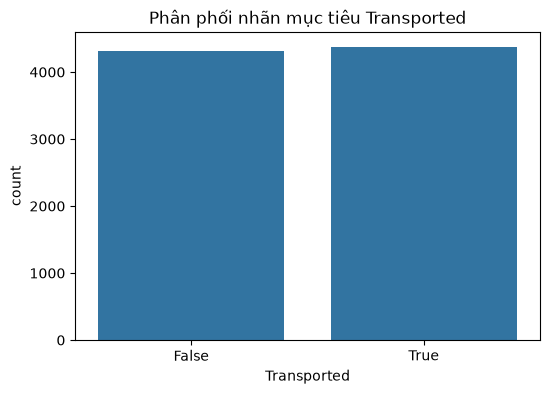

Tỉ lệ phân phối nhãn:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [2]:
# Tải tập dữ liệu (Đảm bảo file train.csv và test.csv nằm cùng thư mục)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test:  {test_df.shape}")

# Hiển thị 5 dòng đầu tập Train
display(train_df.head())

# Kiểm tra tỉ lệ nhãn mục tiêu (Target Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Transported')
plt.title('Phân phối nhãn mục tiêu Transported')
plt.show()

print("Tỉ lệ phân phối nhãn:")
print(train_df['Transported'].value_counts(normalize=True))

## 2. Tiền xử lý & Trích xuất Đặc trưng (Feature Engineering)

### Các logic cần áp dụng:
1. **Quy tắc Chi tiêu (Expenditure Logic):** 
   - Chi tiêu gồm 5 khoản: `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.
   - Nếu `CryoSleep == True` $\rightarrow$ Tất cả các khoản chi tiêu = 0.
   - Nếu `TotalSpending > 0` $\rightarrow$ `CryoSleep` = `False`.
   - Trẻ em (Tuổi < 13) $\rightarrow$ Chi tiêu = 0.
2. **Trích xuất thông tin:**
   - `Cabin`: Tách thành `Deck` (Tầng), `Num` (Số phòng), `Side` (Mạn tàu P - Port / S - Starboard).
   - `PassengerId`: Tách thành `Group` (Nhóm) và `GroupSize` (Kích thước nhóm).

In [3]:
def process_data(df_input):
    df = df_input.copy()
    
    # 1. Chi tiêu (Expenditure Columns)
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    
    # Impute chi tiêu = 0 nếu đang CryoSleep hoặc Tuổi < 13
    for col in spend_cols:
        df.loc[df['CryoSleep'] == True, col] = df.loc[df['CryoSleep'] == True, col].fillna(0)
        df.loc[df['Age'] < 13, col] = df.loc[df['Age'] < 13, col].fillna(0)
        df[col] = df[col].fillna(df[col].median())
        
    # Tạo đặc trưng Tổng chi tiêu & Cờ chi tiêu
    df['TotalSpending'] = df[spend_cols].sum(axis=1)
    df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
    
    # Impute CryoSleep dựa trên chi tiêu
    df.loc[(df['CryoSleep'].isna()) & (df['TotalSpending'] > 0), 'CryoSleep'] = False
    df.loc[(df['CryoSleep'].isna()) & (df['TotalSpending'] == 0), 'CryoSleep'] = True
    df['CryoSleep'] = df['CryoSleep'].astype(bool)
    
    # 2. Tách PassengerId -> Group & GroupSize
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    group_sizes = df['Group'].value_counts().to_dict()
    df['GroupSize'] = df['Group'].map(group_sizes)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
    
    # 3. Tách Cabin -> Deck, Num, Side
    df['Cabin'] = df['Cabin'].fillna('Unknown/None/Unknown')
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0] if x != 'Unknown/None/Unknown' else 'Unknown')
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2] if x != 'Unknown/None/Unknown' else 'Unknown')
    
    # Impute thuộc tính Phân loại còn thiếu bằng Mode
    cat_cols = ['HomePlanet', 'Destination', 'VIP']
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    # Impute Tuổi bằng Median
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    return df

# Hợp nhất Train và Test để đồng bộ Feature Engineering
all_data = pd.concat([train_df.assign(is_train=1), test_df.assign(is_train=0, Transported=False)], ignore_index=True)
all_processed = process_data(all_data)

# Tách lại Train và Test
train_proc = all_processed[all_processed['is_train'] == 1].drop(columns=['is_train'])
test_proc = all_processed[all_processed['is_train'] == 0].drop(columns=['is_train', 'Transported'])

print("Số đặc trưng sau xử lý:", train_proc.shape[1])
train_proc.head(3)

Số đặc trưng sau xử lý: 21


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpending,NoSpending,Group,GroupSize,IsAlone,Deck,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,1,0001,1,1,B,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,0,0002,1,1,F,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,0,0003,2,0,A,S


## 3. Encoding & Feature Selection
Chuyển đổi các cột chuỗi (Categorical Features) sang dạng số để đưa vào các mô hình học máy.

In [4]:
features_to_drop = ['PassengerId', 'Name', 'Cabin', 'Group', 'Transported']
features = [c for c in train_proc.columns if c not in features_to_drop]

# Mã hóa Label Encoding cho các biến Phân loại
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit trên toàn bộ dữ liệu đã xử lý để tránh lỗi Unseen Labels
    le.fit(all_processed[col].astype(str))
    train_proc[col] = le.transform(train_proc[col].astype(str))
    test_proc[col] = le.transform(test_proc[col].astype(str))
    label_encoders[col] = le

X = train_proc[features].copy()
y = train_proc['Transported'].astype(int).values
X_test = test_proc[features].copy()

print(f"Danh sách {len(features)} đặc trưng dùng cho mô hình:")
print(features)

Danh sách 16 đặc trưng dùng cho mô hình:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'NoSpending', 'GroupSize', 'IsAlone', 'Deck', 'Side']


## 4. Stratified 5-Fold Cross Validation & Base Models Benchmark

Sử dụng **Stratified K-Fold (K=5)** để đảm bảo tỉ lệ nhãn đồng đều giữa các fold.
Đồng thời thu thập dự đoán **Out-Of-Fold (OOF)** từ từng mô hình để phục vụ cho bước Ensemble Stacking tiếp theo.

In [5]:
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Khởi tạo ma trận lưu OOF predictions
oof_lgb = np.zeros(len(train_proc))
oof_xgb = np.zeros(len(train_proc))
oof_cat = np.zeros(len(train_proc))

preds_lgb = np.zeros(len(test_proc))
preds_xgb = np.zeros(len(test_proc))
preds_cat = np.zeros(len(test_proc))

print("=== BẮT ĐẦU HUẤN LUYỆN BASE MODELS ===")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y[train_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]
    
    # 1. LightGBM
    model_lgb = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1)
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    preds_lgb += model_lgb.predict_proba(X_test)[:, 1] / FOLDS
    
    # 2. XGBoost
    model_xgb = xgb.XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=5, random_state=42, eval_metric='logloss')
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    preds_xgb += model_xgb.predict_proba(X_test)[:, 1] / FOLDS
    
    # 3. CatBoost
    model_cat = CatBoostClassifier(iterations=700, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]
    preds_cat += model_cat.predict_proba(X_test)[:, 1] / FOLDS

# Đánh giá Benchmark các mô hình đơn lẻ
print("\n--- BENCHMARK BASE MODELS ACCURACY (OOF) ---")
print(f"LightGBM OOF Accuracy: {accuracy_score(y, oof_lgb > 0.5):.4f}")
print(f"XGBoost  OOF Accuracy: {accuracy_score(y, oof_xgb > 0.5):.4f}")
print(f"CatBoost OOF Accuracy: {accuracy_score(y, oof_cat > 0.5):.4f}")

=== BẮT ĐẦU HUẤN LUYỆN BASE MODELS ===

--- BENCHMARK BASE MODELS ACCURACY (OOF) ---
LightGBM OOF Accuracy: 0.8070
XGBoost  OOF Accuracy: 0.8069
CatBoost OOF Accuracy: 0.8102


## 5. Stacking Ensemble Learning

Chúng ta tạo tập dữ liệu mới từ xác suất dự đoán OOF của 3 mô hình cơ sở:
$$X_{meta} = [\text{OOF}_{LGB}, \text{OOF}_{XGB}, \text{OOF}_{CAT}]$$

Sử dụng mô hình tuyền tính đơn giản (**Logistic Regression**) làm Meta-Learner để kết hợp tối ưu trọng số của từng mô hình mà không bị overfitting.

In [6]:
# Tạo tập dữ liệu Meta cho Train và Test
X_meta_train = np.column_stack((oof_lgb, oof_xgb, oof_cat))
X_meta_test = np.column_stack((preds_lgb, preds_xgb, preds_cat))

# Meta-Learner: Logistic Regression
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y)

# Dự đoán OOF của Stacking Model
oof_stacking = meta_model.predict_proba(X_meta_train)[:, 1]
final_train_acc = accuracy_score(y, oof_stacking > 0.5)

print("=" * 45)
print(f"🔥 FINAL STACKING ENSEMBLE OOF ACCURACY: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print("=" * 45)

# Bảng so sánh mô hình
benchmark_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost', 'Stacking (Ensemble)'],
    'OOF Accuracy': [
        accuracy_score(y, oof_lgb > 0.5),
        accuracy_score(y, oof_xgb > 0.5),
        accuracy_score(y, oof_cat > 0.5),
        final_train_acc
    ]
})
display(benchmark_df)

🔥 FINAL STACKING ENSEMBLE OOF ACCURACY: 0.8111 (81.11%)


,Model,OOF Accuracy
0,LightGBM,0.806971
1,XGBoost,0.806856
2,CatBoost,0.810192
3,Stacking (Ensemble),0.811112


## 6. Dự đoán trên tập Test & Xuất file `submission.csv`

Áp dụng mô hình Stacking Ensemble đã huấn luyện để dự đoán trên tập dữ liệu Test của Kaggle.

In [7]:
# Dự đoán xác suất trên tập Test từ Meta-Learner
test_preds_proba = meta_model.predict_proba(X_meta_test)[:, 1]

# Chuyển đổi thành nhãn Boolean (True/False) theo yêu cầu Kaggle
final_predictions = test_preds_proba > 0.5

# Tạo DataFrame kết quả
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_predictions
})

# Xuất file CSV
submission.to_csv('submission.csv', index=False)
print("Đã tạo thành công file 'submission.csv'!")

# Kiểm tra định dạng 5 dòng đầu
display(submission.head())

# Kiểm tra phân phối dự đoán trên tập test
print("\nPhân phối nhãn dự đoán tập Test:")
print(submission['Transported'].value_counts(normalize=True))

Đã tạo thành công file 'submission.csv'!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True



Phân phối nhãn dự đoán tập Test:
Transported
True     0.535656
False    0.464344
Name: proportion, dtype: float64
